# Part 1: Logistic Regression

In [248]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [249]:
# Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [250]:
# TODO: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_copy = X_train
X_test_copy = X_test
y_train_copy = y_train
y_test_copy = y_test

In [251]:
# Normalize the feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [252]:
# Implement Logistic Regression algorithm

# TODO: Implement the sigmoid function. Refer to the formula in the homework4.docx file
def sigmoid(z):
    # make sure to use the z variable in the formula
    formula = 1 / (1 + np.exp(-z))

    return formula

def logistic_regression(X, y, learning_rate, num_iterations):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0

    # we need to update the weights and bias using gradient descent. Complete the code below
    for _ in range(num_iterations):
        # TODO: combine the inputs and weights together, and then add bias. Assign this value to z
        z = np.dot(X, weights) + bias

        # TODO: need to output probabilities betwen 0 and 1 (HINT: use the sigmoid function)
        y_predicted = sigmoid(z)

        # Compute the gradients

        # TODO: dw is the gradient of the loss function w.r.t. the weights
        dw = (1/n_samples) * np.dot(X.T, y_predicted - y)

        # TODO: db is the gradient of the loss function w.r.t. the bias
        db = (1/n_samples) * np.sum(y_predicted - y) 

        # TODO: update the weights and bias using the computed gradients (HINT: use the learning rate)
        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias


In [253]:
# Train Logistic Regression model
# TODO: Find good values for learning_rate and num_iterations
learning_rate = 0.01
num_iterations = 1000
weights, bias = logistic_regression(X_train_scaled, y_train, learning_rate, num_iterations)

# Predict class labels using trained model
def predict(X, weights, bias):
    z = np.dot(X, weights) + bias
    y_predicted = sigmoid(z)
    y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
    return y_predicted_cls

In [254]:
y_pred = predict(X_test_scaled, weights, bias)

# Evaluate the model's performance
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = np.mean(y_pred == y_test)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", acc)

Precision: 0.9859154929577465
Recall: 0.9859154929577465
F1 Score: 0.9859154929577465
Accuracy: 0.9824561403508771


# Part 2: Perceptron

Ensure that PyTorch is installed before this section, as we will utilize this powerful library. For installation, check this link - [https://pytorch.org/get-started/locally/](https://pytorch.org/get-started/locally/)

In [255]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [256]:
# TODO: Concatenate 1's to the X_train_scaled and X_test_scaled from above
# Hint: You'll probably want to use the numpy concatenate operation
train_ones = np.ones((X_train_scaled.shape[0], 1))
test_ones = np.ones((X_test_scaled.shape[0], 1))

X_train_wones = np.concatenate([X_train_scaled, train_ones], axis=1)
X_test_wones = np.concatenate([X_test_scaled, test_ones], axis=1)

In [257]:
# TODO: Define the Perceptron class including an __init__ function and a forward function
class Perceptron():
    # TODO: initialze the weight vector w
    def __init__(self, input_size):
        self.w = np.zeros(input_size)

    # TODO: classify a single example x using sgn(𝐰^T x + b)
    # Hint: make sure the output labels are correct
    def forward(self, x):
        output = np.sign(np.dot(self.w.T, x))
        if output == -1:
            return 0
        return output

    # Implement the perceptron learning algorithm from slides
    def update(self, x, y, learning_rate):
        # If prediction is positive but true value is negative
        prediction = self.forward(x)
        true_value = y

        if true_value == 1 and prediction == 0:
            new_weights = true_value * learning_rate * x
            self.w = new_weights
            
        elif true_value == 0 and prediction == 1:
            true_value = -1
            new_weights = true_value * learning_rate * x
            self.w = new_weights

In [258]:
# Train the model
# TODO: Find good values for learning_rate and num_iterations
learning_rate = 0.01
num_iterations = 1000
input_size = X_train_wones.shape[1] # Note this is the input size with the 1's trick
perceptron = Perceptron(input_size)
for _ in range(num_iterations):
  for x_i, y_i in zip(X_train_wones, y_train):
    perceptron.update(x_i, y_i, learning_rate)

In [259]:
# Evaluate the model
# Should get around 95% accuracy
correct_count = 0
for x_i, y_i in zip(X_test_wones, y_test):
  prediction = perceptron.forward(x_i)
  if (prediction == y_i):
    correct = True
  else:
    correct = False
  if correct:
    correct_count += 1
accuracy = float(correct_count) / len(y_test)
print("Test accuracy: %f" % accuracy)

Test accuracy: 0.947368


# Part 3: Data Preperation

In [260]:
# First, make sure the values of X_train, X_test, y_train, y_test are set correctly from Assignment 1 and not overwritten
# If necessary, go back and rerun the original cell to make sure you have those correct values
print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[9.029e+00 1.733e+01 5.879e+01 ... 1.750e-01 4.228e-01 1.175e-01]
 [2.109e+01 2.657e+01 1.427e+02 ... 2.903e-01 4.098e-01 1.284e-01]
 [9.173e+00 1.386e+01 5.920e+01 ... 5.087e-02 3.282e-01 8.490e-02]
 ...
 [1.429e+01 1.682e+01 9.030e+01 ... 3.333e-02 2.458e-01 6.120e-02]
 [1.398e+01 1.962e+01 9.112e+01 ... 1.827e-01 3.179e-01 1.055e-01]
 [1.218e+01 2.052e+01 7.722e+01 ... 7.431e-02 2.694e-01 6.878e-02]]
[[1.247e+01 1.860e+01 8.109e+01 ... 1.015e-01 3.014e-01 8.750e-02]
 [1.894e+01 2.131e+01 1.236e+02 ... 1.789e-01 2.551e-01 6.589e-02]
 [1.546e+01 1.948e+01 1.017e+02 ... 1.514e-01 2.837e-01 8.019e-02]
 ...
 [1.152e+01 1.493e+01 7.387e+01 ... 9.608e-02 2.664e-01 7.809e-02]
 [1.422e+01 2.785e+01 9.255e+01 ... 8.219e-02 1.890e-01 7.796e-02]
 [2.073e+01 3.112e+01 1.357e+02 ... 1.659e-01 2.868e-01 8.218e-02]]
[1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0
 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 1
 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0

In [261]:
# TODO: Rewrite the logistic regression code to include test evals at every n iterations
# Should now return test accuracy every n iterations
def logistic_regression_with_eval(X, y, X_test, y_test, learning_rate, num_iterations, eval_every=1):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    train_acc_all = []
    test_acc_all = []

    # Fill in with old solution
    for i in range(num_iterations):
        # Add your code from above

        # we need to update the weights and bias using gradient descent. Complete the code below
        # TODO: combine the inputs and weights together, and then add bias. Assign this value to z
        z = np.dot(X, weights) + bias

        # TODO: need to output probabilities betwen 0 and 1 (HINT: use the sigmoid function)
        y_predicted = sigmoid(z)

        # Compute the gradients

        # TODO: dw is the gradient of the loss function w.r.t. the weights
        dw = (1/n_samples) * np.dot(X.T, y_predicted - y)

        # TODO: db is the gradient of the loss function w.r.t. the bias
        db = (1/n_samples) * np.sum(y_predicted - y) 

        # TODO: update the weights and bias using the computed gradients (HINT: use the learning rate)
        weights -= learning_rate * dw
        bias -= learning_rate * db


        # Add new code here
        if i % eval_every == 0:
         # Train Logistic Regression model

         # Train accuracy
         correct_count = 0
         for x_i, y_i in zip(X, y):
            z = np.dot(x_i, weights.T) + bias
            prediction = sigmoid(z)
            if prediction < 0.5:
               prediction = 0
            else:
               prediction = 1

            if prediction == y_i:
               correct_count += 1

         accuracy = correct_count / n_samples
         train_acc_all.append(accuracy)
         
         # Test accuracy
         correct_count = 0
         for x_i, y_i in zip(X_test, y_test):
            z = np.dot(x_i, weights.T) + bias
            prediction = sigmoid(z)
            if prediction < 0.5:
               prediction = 0
            else:
               prediction = 1

            if prediction == y_i:
               correct_count += 1

         accuracy = correct_count / len(X_test)
         test_acc_all.append(accuracy)

    return weights, bias, train_acc_all, test_acc_all

In [262]:
import matplotlib.pyplot as plt

In [263]:
# Take your solution from above and plot the train and test curves
# TODO: Copy hyperparamers from your solution above
learning_rate = 0.1
num_iterations = 100
weights_scaled, bias_scaled, train_acc_scaled, test_acc_scaled = logistic_regression_with_eval(
    X_train_scaled, y_train, X_test_scaled, y_test, learning_rate, num_iterations, eval_every=1)

# Make sure you get the same values as before
y_pred = predict(X_test_scaled, weights, bias)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = np.mean(y_pred == y_test)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", acc)

Precision: 0.9859154929577465
Recall: 0.9859154929577465
F1 Score: 0.9859154929577465
Accuracy: 0.9824561403508771


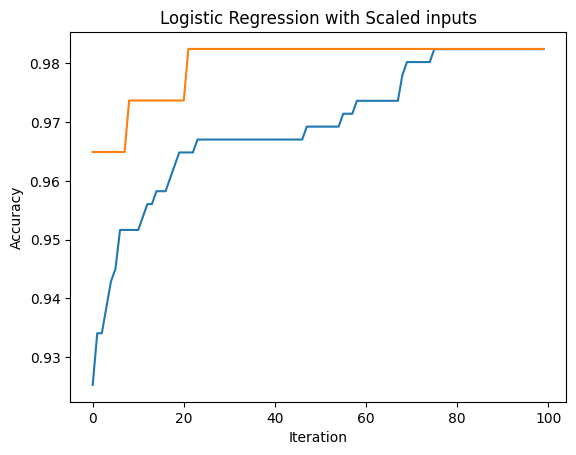

[-0.37669016 -0.35637561 -0.37310421 -0.37317791 -0.1503151  -0.12870258
 -0.29018915 -0.39822726 -0.09644156  0.14999429 -0.32912149 -0.00880922
 -0.27638397 -0.29673281 -0.00096203  0.11576104  0.09110313 -0.04460336
  0.07283936  0.19386635 -0.44541565 -0.43547625 -0.42545018 -0.42058716
 -0.30095185 -0.20714354 -0.28923105 -0.39881592 -0.30809461 -0.09047177] 0.3541643072659761


In [269]:
# TODO:
# Using Matplotlib, make a plot with #iterations on the x axis and train and test accuracy on the y_axis
# Recall, we asked you to make simple plots in HW1
plt.title('Logistic Regression with Scaled inputs')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

array = []
for i in range(100):
    array.append(i)
    
# Plot both train and test accuracy
plt.plot(array, train_acc_scaled, label="Train accuracy")
plt.plot(array, test_acc_scaled, label="Test accuracy")
plt.show()

print(weights_scaled, bias_scaled)

C:\Users\Khongor\AppData\Local\Temp\ipykernel_53296\4199479962.py:6: RuntimeWarning: overflow encountered in exp
  formula = 1 / (1 + np.exp(-z))
c:\Users\Khongor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Accuracy: 0.37719298245614036


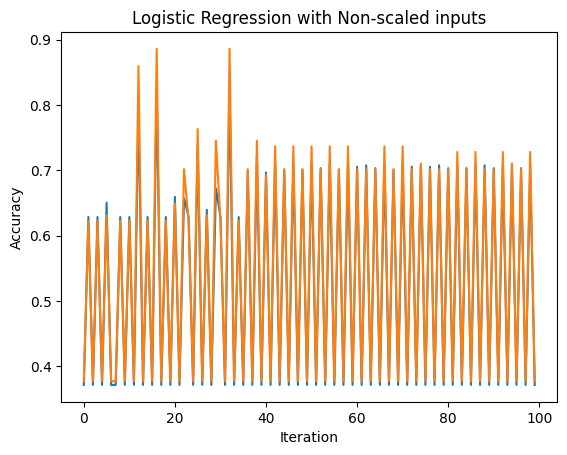

[ 1.32994931e+01  2.48535315e+01  8.12259418e+01  8.55850546e+01
  1.40411419e-01  4.59822186e-02 -7.84863168e-02 -4.25863179e-02
  2.66154394e-01  1.07033520e-01  8.95529251e-02  2.01300350e+00
  5.57461666e-01 -2.57091303e+01  1.24295683e-02  2.26862911e-02
  2.47407583e-02  9.70856084e-03  3.37962664e-02  5.94212508e-03
  1.27001847e+01  3.12526856e+01  7.73400998e+01 -1.24265506e+02
  1.82357074e-01  4.66139538e-02 -1.08644923e-01 -2.21342762e-02
  3.74608313e-01  1.19220598e-01] 1.6959037939839225


In [268]:
# TODO - re-train and replot logistic regression without doing any input rescaling
# This should mostly be copying code from above but using the unscaled data

# Take your solution from above and plot the train and test curves
# TODO: Copy hyperparamers from your solution above
learning_rate = 0.1
num_iterations = 100
weights, bias, train_acc, test_acc = logistic_regression_with_eval(X_train_copy, y_train_copy, X_test_copy, y_test_copy, learning_rate, num_iterations, eval_every=1)

# Make sure you get the same values as before
y_pred = predict(X_test, weights, bias)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = np.mean(y_pred == y_test)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy:", acc)

plt.title('Logistic Regression with Non-scaled inputs')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

array = []
for i in range(100):
    array.append(i)
    
# Plot both train and test accuracy
plt.plot(array, train_acc, label="Train accuracy")
plt.plot(array, test_acc, label="Test accuracy")
plt.show()

print(weights, bias)

What do you notice about the training curves and accuracy?

TODO: ANSWER 

Without scaling, I noticed the model gives errors and completely crashes. And he accuracy is quite strange, its jumping between approximately 0.4 and 0.7. 

One of the errors is "overflow", this is from trying to compute e to the power of over 100's. Which gives a numerical overflow. If z in the formula is not contained, it can grow to large magnitude numbers that causes overflow when applied to e. 

Examine the weights for both the scaled and unscaled logistic regression? What do you notice?

In [266]:
# Compare weights

TODO: ANSWER

Surprisingly, the weights for the unscaled model were quite varied. But for the scaled model the weights were quite uniform and stable. For the unscaled model, the weights looked like they had a range from -10 to 10. 